# 02 - TRAIN MODEL

In [1]:
import torch
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
%env CUDA_LAUNCH_BLOCKING=1

Usando dispositivo: cuda
env: CUDA_LAUNCH_BLOCKING=1


In [3]:
from google.colab import drive
drive.mount('/content/drive')
url_pref="drive/MyDrive/Colab Notebooks/"

Mounted at /content/drive


## 1 - IMPORT SPLITTED DATA

In [10]:
# Crear DataLoader usando señales y labels binarios (0/1) para entrenamiento desde archivos chunked zip
import torch
from torch.utils.data import TensorDataset, DataLoader
import zipfile
import os
import tempfile

def load_signals_from_zip(zip_path):
    signals_list, labels_list = [], []
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        pt_files = [f for f in zipf.namelist() if f.endswith('.pt')]
        with tempfile.TemporaryDirectory() as tmpdir:
            for pt_file in pt_files:
                zipf.extract(pt_file, tmpdir)
                pt_path = os.path.join(tmpdir, pt_file)
                data = torch.load(pt_path)
                signals_list.append(data['signals'])
                labels_list.append(data['labels'])
    signals = torch.cat(signals_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    return signals, labels

# Cargar los datos preparados desde los zip chunked
train_signals, train_labels = load_signals_from_zip(url_pref+'TORCH/train_data_chunks.zip')
val_signals, val_labels = load_signals_from_zip(url_pref+'TORCH/val_data_chunks.zip')
test_signals, test_labels = load_signals_from_zip(url_pref+'TORCH/test_data_chunks.zip')

# Asegurarse que los labels sean float y binarios (0/1)
train_labels = train_labels.float().clamp(0, 1)
val_labels = val_labels.float().clamp(0, 1)
test_labels = test_labels.float().clamp(0, 1)

# Crear TensorDataset y DataLoader
train_dataset = TensorDataset(train_signals, train_labels)
val_dataset = TensorDataset(val_signals, val_labels)
test_dataset = TensorDataset(test_signals, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print('Ejemplo de batch de señales:', next(iter(train_loader))[0].shape)
print('Ejemplo de batch de labels:', next(iter(train_loader))[1][:10])

Ejemplo de batch de señales: torch.Size([16, 12, 2500])
Ejemplo de batch de labels: tensor([0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2 - CREATE TRAINNING MODEL

In [11]:
class ECGNet(nn.Module):
    def __init__(self, input_channels=12):
        super(ECGNet, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        return torch.sigmoid(self.fc(x))

class ECGNet_v2(nn.Module):
    def __init__(self, input_channels=12):
        super(ECGNet_v2, self).__init__()

        self.cnn = nn.Sequential(
            # Bloque 1
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            # Bloque 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),

            # Bloque 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),

            # Bloque 4 extra (más capacidad)
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.AdaptiveAvgPool1d(1),  # colapsa la dimensión temporal
            nn.Dropout(0.4)
        )

        # Clasificador final
        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)  # salida sin sigmoid
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)  # aplanar [batch, channels]
        x = self.fc(x)
        return x  # salida sin sigmoid → usar BCEWithLogitsLoss



### MODEL 1

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ECGNet().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Learning rate más bajo



In [13]:

# Entrenar el modelo
model = ECGNet().to(device)
criterion = nn.BCELoss()


# Tensor con el peso de la clase positiva
pos_weight = torch.tensor([19.0], device=device)  # 0.95/0.05 = 19

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Learning rate más bajo

print("Iniciando entrenamiento...")
print(f"Total de parámetros: {sum(p.numel() for p in model.parameters())}")

for epoch in range(20):  # Más épocas
    # Entrenamiento
    model.train()
    train_loss = 0
    train_samples = 0

    for batch_idx, (signals, labels) in enumerate(train_loader):
        #signals, labels = signals.to(device).float(), labels.to(device).unsqueeze(1)
        signals, labels = signals.to(device).float(), labels.to(device).float().unsqueeze(1)


        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_samples += len(signals)

    # Validación
    model.eval()
    val_loss, all_labels, all_preds = 0, [], []

    with torch.no_grad():
        for signals, labels in test_loader:
            #signals, labels = signals.to(device).float(), labels.to(device).unsqueeze(1)
            signals, labels = signals.to(device).float(), labels.to(device).float().unsqueeze(1)

            outputs = model(signals)
            val_loss += criterion(outputs, labels).item()
            all_labels.extend(labels.cpu().numpy().flatten())
            #all_preds.extend(outputs.cpu().numpy().flatten())
            probs = torch.sigmoid(outputs)
            all_preds.extend(probs.cpu().numpy().flatten())


    # Métricas
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)

    try:
        auc = roc_auc_score(all_labels, all_preds)
    except ValueError:
        auc = 0.0  # Si solo hay una clase en validación

    acc = accuracy_score(all_labels, np.round(all_preds))

    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | AUC: {auc:.4f} | Acc: {acc:.4f}")

print("Entrenamiento completado!")

# Guardar el modelo
torch.save(model.state_dict(), 'ecg_mortality_model.pth')
print("Modelo guardado como 'ecg_mortality_model.pth'")

Iniciando entrenamiento...
Total de parámetros: 38305
Epoch  1 | Train Loss: 1.1415 | Val Loss: 1.0499 | AUC: 0.9621 | Acc: 0.0499
Epoch  2 | Train Loss: 1.0214 | Val Loss: 1.0456 | AUC: 0.9839 | Acc: 0.0518
Epoch  3 | Train Loss: 1.0030 | Val Loss: 0.9987 | AUC: 0.9937 | Acc: 0.5331
Epoch  4 | Train Loss: 0.9935 | Val Loss: 0.9905 | AUC: 0.9929 | Acc: 0.3752
Epoch  5 | Train Loss: 0.9897 | Val Loss: 0.9791 | AUC: 0.9964 | Acc: 0.4566
Epoch  6 | Train Loss: 0.9870 | Val Loss: 0.9827 | AUC: 0.9941 | Acc: 0.4676
Epoch  7 | Train Loss: 0.9842 | Val Loss: 1.0004 | AUC: 0.9931 | Acc: 0.4134
Epoch  8 | Train Loss: 0.9842 | Val Loss: 0.9715 | AUC: 0.9967 | Acc: 0.6372
Epoch  9 | Train Loss: 0.9792 | Val Loss: 0.9773 | AUC: 0.9976 | Acc: 0.5638
Epoch 10 | Train Loss: 0.9767 | Val Loss: 0.9710 | AUC: 0.9952 | Acc: 0.8028
Epoch 11 | Train Loss: 0.9777 | Val Loss: 0.9732 | AUC: 0.9967 | Acc: 0.8001
Epoch 12 | Train Loss: 0.9756 | Val Loss: 0.9715 | AUC: 0.9977 | Acc: 0.7334
Epoch 13 | Train Loss:

### MODEL 2

In [ ]:

# Entrenar el modelo
model = ECGNet_v2().to(device)
#criterion = nn.BCELoss()


# Tensor con el peso de la clase positiva
pos_weight = torch.tensor([19.0], device=device)  # 0.95/0.05 = 19

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)  # Learning rate más bajo

print("Iniciando entrenamiento...")
print(f"Total de parámetros: {sum(p.numel() for p in model.parameters())}")

for epoch in range(20):  # Más épocas
    # Entrenamiento
    model.train()
    train_loss = 0
    train_samples = 0

    for batch_idx, (signals, labels) in enumerate(train_loader):
        #signals, labels = signals.to(device).float(), labels.to(device).unsqueeze(1)
        signals, labels = signals.to(device).float(), labels.to(device).float().unsqueeze(1)


        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_samples += len(signals)

    # Validación
    model.eval()
    val_loss, all_labels, all_preds = 0, [], []

    with torch.no_grad():
        for signals, labels in test_loader:
            #signals, labels = signals.to(device).float(), labels.to(device).unsqueeze(1)
            signals, labels = signals.to(device).float(), labels.to(device).float().unsqueeze(1)

            outputs = model(signals)
            val_loss += criterion(outputs, labels).item()
            all_labels.extend(labels.cpu().numpy().flatten())
            #all_preds.extend(outputs.cpu().numpy().flatten())
            probs = torch.sigmoid(outputs)
            all_preds.extend(probs.cpu().numpy().flatten())


    # Métricas
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(test_loader)

    try:
        auc = roc_auc_score(all_labels, all_preds)
    except ValueError:
        auc = 0.0  # Si solo hay una clase en validación

    acc = accuracy_score(all_labels, np.round(all_preds))

    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | AUC: {auc:.4f} | Acc: {acc:.4f}")

print("Entrenamiento completado!")

# Guardar el modelo
torch.save(model.state_dict(), 'ecg_mortality_model.pth')
print("Modelo guardado como 'ecg_mortality_model.pth'")

In [ ]:
torch.save(model.state_dict(), 'ecg_mortality_model.pth')
print("Entrenamiento completado!")
torch.save(model.state_dict(), "ecg_mortality_model.pth")
print("Modelo guardado como 'ecg_mortality_model.pth'")
torch.save({'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()}, 'ecg_mortality_optimizer.pth')
print("Optimizador guardado como ecg_mortality_model.pth")





### SAVING

In [ ]:
torch.save({
    'model_class': model.__class__.__name__,
    'model_args': {...},  # si tu modelo necesita parámetros para inicializarse
    'model_state_dict': model.state_dict(),
}, 'ecg_mortality_model.pth')


In [ ]:

torch.save(train_signals, 'train_signals.pt')
torch.save(train_labels, 'train_labels.pt')
torch.save(val_signals, 'val_signals.pt')
torch.save(val_labels, 'val_labels.pt')

In [14]:
# Evaluación detallada del modelo
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("=== EVALUACIÓN FINAL DEL MODELO ===")

# Evaluar en conjunto de entrenamiento
model.eval()
train_labels, train_preds = [], []

with torch.no_grad():
    for signals, labels in train_loader:
        signals, labels = signals.to(device), labels.to(device)
        outputs = model(signals)
        train_labels.extend(labels.cpu().numpy())
        train_preds.extend(outputs.cpu().numpy().flatten())

# Ahora sí
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(val_labels, val_preds))
print(classification_report(val_labels, val_preds, target_names=['Supervivencia', 'Mortalidad']))



# Evaluar en conjunto de validación
val_labels, val_preds = [], []
with torch.no_grad():
    for signals, labels in test_loader:
        signals, labels = signals.to(device), labels.to(device)
        outputs = model(signals)
        val_labels.extend(labels.cpu().numpy())
        val_preds.extend(outputs.cpu().numpy().flatten())

# Métricas finales
print(f"\n--- CONJUNTO DE ENTRENAMIENTO ---")
train_auc = roc_auc_score(train_labels, train_preds)
train_acc = accuracy_score(train_labels, np.round(train_preds))
print(f"AUC: {train_auc:.4f}")
print(f"Accuracy: {train_acc:.4f}")

print(f"\n--- CONJUNTO DE VALIDACIÓN ---")
val_auc = roc_auc_score(val_labels, val_preds)
val_acc = accuracy_score(val_labels, np.round(val_preds))
print(f"AUC: {val_auc:.4f}")
print(f"Accuracy: {val_acc:.4f}")

# Matriz de confusión
print(f"\n--- MATRIZ DE CONFUSIÓN (VALIDACIÓN) ---")
cm = confusion_matrix(val_labels, np.round(val_preds))
print(cm)

# Reporte de clasificación
print(f"\n--- REPORTE DE CLASIFICACIÓN (VALIDACIÓN) ---")
print(classification_report(val_labels, np.round(val_preds), target_names=['Supervivencia', 'Mortalidad']))

# Distribución de predicciones
print(f"\n--- DISTRIBUCIÓN DE DATOS ---")
print(f"Training - Mortalidad: {sum(train_labels)}/{len(train_labels)} ({100*sum(train_labels)/len(train_labels):.1f}%)")
print(f"Validation - Mortalidad: {sum(val_labels)}/{len(val_labels)} ({100*sum(val_labels)/len(val_labels):.1f}%)")

print(f"\n--- INFORMACIÓN DEL MODELO ---")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")
print(f"Parámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Tamaño del modelo guardado: ecg_mortality_model.pth")


=== EVALUACIÓN FINAL DEL MODELO ===


RuntimeError: Input type (c10::Half) and bias type (float) should be the same

In [15]:
# ==================== EVALUACIÓN FINAL DEL MODELO ====================

from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
import torch

print("=== EVALUACIÓN FINAL DEL MODELO ===")

model.eval()

# ---------------------------------------------
# Evaluación en conjunto de validación
# ---------------------------------------------
val_labels, val_probs, val_preds = [], [], []

with torch.no_grad():
    for signals, labels in test_loader:
        #signals, labels = signals.to(device), labels.to(device).float().unsqueeze(1)
        signals, labels = signals.to(device).float(), labels.to(device).float().unsqueeze(1)

        outputs = model(signals)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).long()

        val_labels.extend(labels.cpu().numpy())
        val_probs.extend(probs.cpu().numpy().flatten())
        val_preds.extend(preds.cpu().numpy().flatten())

# ---------------------------------------------
# Métricas
# ---------------------------------------------

print("\n--- CONJUNTO DE VALIDACIÓN ---")
val_auc = roc_auc_score(val_labels, val_probs)
val_acc = accuracy_score(val_labels, val_preds)
print(f"AUC: {val_auc:.4f}")
print(f"Accuracy: {val_acc:.4f}")

# ---------------------------------------------
# Matriz de confusión
# ---------------------------------------------
print("\n--- MATRIZ DE CONFUSIÓN (VALIDACIÓN) ---")
cm = confusion_matrix(val_labels, val_preds)
print(cm)

# ---------------------------------------------
# Reporte de clasificación
# ---------------------------------------------
print("\n--- REPORTE DE CLASIFICACIÓN (VALIDACIÓN) ---")
report = classification_report(val_labels, val_preds, target_names=['Supervivencia', 'Mortalidad'])
print(report)

# ---------------------------------------------
# Información del modelo
# ---------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\n--- INFORMACIÓN DEL MODELO ---")
print(f"Parámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Tamaño del modelo guardado: ecg_mortality_model.pth")


=== EVALUACIÓN FINAL DEL MODELO ===

--- CONJUNTO DE VALIDACIÓN ---
AUC: 0.9985
Accuracy: 0.7630

--- MATRIZ DE CONFUSIÓN (VALIDACIÓN) ---
[[2976  988]
 [   0  204]]

--- REPORTE DE CLASIFICACIÓN (VALIDACIÓN) ---
               precision    recall  f1-score   support

Supervivencia       1.00      0.75      0.86      3964
   Mortalidad       0.17      1.00      0.29       204

     accuracy                           0.76      4168
    macro avg       0.59      0.88      0.57      4168
 weighted avg       0.96      0.76      0.83      4168


--- INFORMACIÓN DEL MODELO ---
Parámetros totales: 38,305
Parámetros entrenables: 38,305
Tamaño del modelo guardado: ecg_mortality_model.pth



--- Test ---
AUC: 0.9985
Accuracy: 0.7630
Balanced Accuracy: 0.8754
Average Precision (PR AUC): 0.9753
F1-score macro: 0.5750
F1-score por clase: [0.85763689 0.29226361]
Precision por clase: [1.         0.17114094]
Recall por clase: [0.75075681 1.        ]
Matthews CC: 0.3584

Matriz de confusión:
[[2976  988]
 [   0  204]]


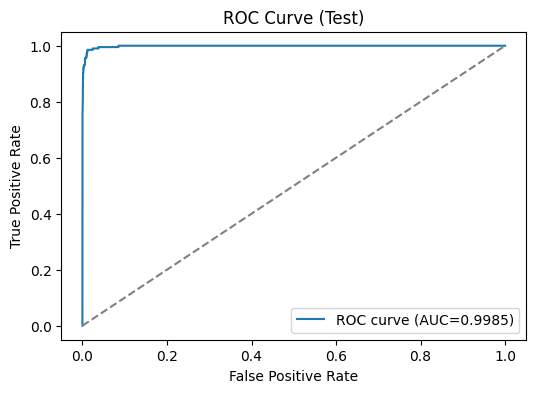

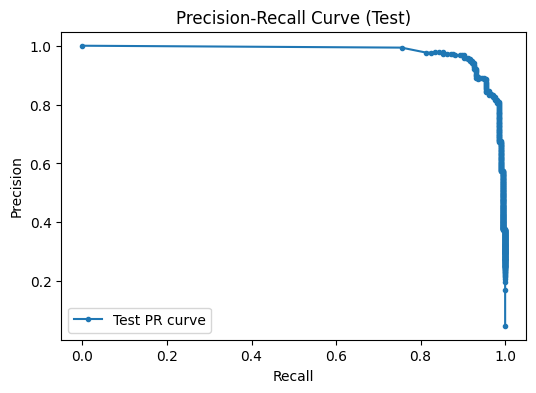

In [16]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, average_precision_score,
    precision_recall_curve, roc_curve, matthews_corrcoef, balanced_accuracy_score
)
import matplotlib.pyplot as plt

def evaluate_model(model, loader, device, dataset_name="Validation"):
    model.eval()
    labels_list, preds_list = [], []

    with torch.no_grad():
        for signals, labels in loader:
            signals, labels = signals.to(device).float(), labels.to(device)
            outputs = model(signals)
            preds = torch.sigmoid(outputs).cpu().numpy().flatten()
            labels_list.extend(labels.cpu().numpy())
            preds_list.extend(preds)

    labels_arr = np.array(labels_list)
    preds_arr = np.array(preds_list)
    preds_binary = np.round(preds_arr)

    # Métricas básicas
    auc = roc_auc_score(labels_arr, preds_arr)
    acc = accuracy_score(labels_arr, preds_binary)
    f1_macro = f1_score(labels_arr, preds_binary, average='macro')
    f1_per_class = f1_score(labels_arr, preds_binary, average=None)
    precision_per_class = precision_score(labels_arr, preds_binary, average=None)
    recall_per_class = recall_score(labels_arr, preds_binary, average=None)
    ap = average_precision_score(labels_arr, preds_arr)
    mcc = matthews_corrcoef(labels_arr, preds_binary)
    bal_acc = balanced_accuracy_score(labels_arr, preds_binary)

    # Impresión de métricas
    print(f"\n--- {dataset_name} ---")
    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"Average Precision (PR AUC): {ap:.4f}")
    print(f"F1-score macro: {f1_macro:.4f}")
    print(f"F1-score por clase: {f1_per_class}")
    print(f"Precision por clase: {precision_per_class}")
    print(f"Recall por clase: {recall_per_class}")
    print(f"Matthews CC: {mcc:.4f}")

    # Matriz de confusión
    cm = confusion_matrix(labels_arr, preds_binary)
    print("\nMatriz de confusión:")
    print(cm)

    # ------------------- Curva ROC -------------------
    fpr, tpr, _ = roc_curve(labels_arr, preds_arr)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC={auc:.4f})')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve ({dataset_name})')
    plt.legend()
    plt.show()

    # Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(labels_arr, preds_arr)
    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, marker='.', label=f'{dataset_name} PR curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve ({dataset_name})')
    plt.legend()
    plt.show()

    return labels_arr, preds_arr

# Evaluar entrenamiento y validación
test_labels, val_preds = evaluate_model(model, test_loader, device, dataset_name="Test")


In [17]:
import numpy as np
import torch
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, average_precision_score, precision_recall_curve, roc_curve,
    matthews_corrcoef, balanced_accuracy_score
)

def evaluate_model_save(model, loader, device, dataset_name="Validation", save_path=None):
    model.eval()
    labels_list, preds_list = [], []

    with torch.no_grad():
        for signals, labels in loader:
            signals, labels = signals.to(device).float(), labels.to(device)
            outputs = model(signals)
            preds = torch.sigmoid(outputs).cpu().numpy().flatten()
            labels_list.extend(labels.cpu().numpy())
            preds_list.extend(preds)

    labels_arr = np.array(labels_list)
    preds_arr = np.array(preds_list)
    preds_binary = np.round(preds_arr)

    # Métricas
    auc = roc_auc_score(labels_arr, preds_arr)
    acc = accuracy_score(labels_arr, preds_binary)
    bal_acc = balanced_accuracy_score(labels_arr, preds_binary)
    ap = average_precision_score(labels_arr, preds_arr)
    f1_macro = f1_score(labels_arr, preds_binary, average='macro')
    f1_per_class = f1_score(labels_arr, preds_binary, average=None)
    precision_per_class = precision_score(labels_arr, preds_binary, average=None)
    recall_per_class = recall_score(labels_arr, preds_binary, average=None)
    mcc = matthews_corrcoef(labels_arr, preds_binary)
    cm = confusion_matrix(labels_arr, preds_binary)

    # Curvas
    fpr, tpr, _ = roc_curve(labels_arr, preds_arr)
    precision_curve, recall_curve, _ = precision_recall_curve(labels_arr, preds_arr)

    # Crear diccionario con todo
    results = {
        "labels": labels_arr,
        "preds_prob": preds_arr,
        "preds_binary": preds_binary,
        "metrics": {
            "auc": auc,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "average_precision": ap,
            "f1_macro": f1_macro,
            "f1_per_class": f1_per_class,
            "precision_per_class": precision_per_class,
            "recall_per_class": recall_per_class,
            "mcc": mcc
        },
        "confusion_matrix": cm,
        "roc_curve": {"fpr": fpr, "tpr": tpr},
        "pr_curve": {"precision": precision_curve, "recall": recall_curve}
    }

    #print(results)
    # Guardar en archivo .npz si se indica path
    if save_path:
        np.savez_compressed(save_path, **results)
        print(f"\nResultados guardados en {save_path}")

    return results


In [18]:
save_file = "evaluation_results.npz"
results = evaluate_model_save(model, test_loader, device, dataset_name="Test", save_path=save_file)



Resultados guardados en evaluation_results.npz


In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score,
    balanced_accuracy_score, matthews_corrcoef, roc_curve
)

# ============================
# Modelo ECGNet_v2
# ============================
class ECGNet_v2(nn.Module):
    def __init__(self, input_channels=12):
        super(ECGNet_v2, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.Dropout(0.3),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.AdaptiveAvgPool1d(1),
            nn.Dropout(0.4)
        )

        self.fc = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)  # salida sin sigmoid
        )

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x  # logits


# ============================
# Entrenamiento
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ECGNet_v2().to(device)

# Pérdida balanceada
pos_weight = torch.tensor([19.0], device=device)  # ejemplo: 95% vs 5%
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

print("Iniciando entrenamiento...")
print(f"Total de parámetros: {sum(p.numel() for p in model.parameters())}")

EPOCHS = 20
for epoch in range(EPOCHS):
    # -------- TRAIN --------
    model.train()
    train_loss = 0

    for signals, labels in train_loader:
        #signals, labels = signals.to(device), labels.to(device).unsqueeze(1)
        signals, labels = signals.to(device).float(), labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # -------- VALID --------
    model.eval()
    val_loss, all_labels, all_preds = 0, [], []

    with torch.no_grad():
        for signals, labels in test_loader:
            #signals, labels = signals.to(device), labels.to(device).unsqueeze(1)
            signals, labels = signals.to(device).float(), labels.to(device).float().unsqueeze(1)

            outputs = model(signals)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs)  # convertir logits a probas
            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(probs.cpu().numpy().flatten())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # AUC
    try:
        auc = roc_auc_score(all_labels, all_preds)
    except ValueError:
        auc = 0.0

    # Mejor umbral (criterio de Youden)
    fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
    best_thresh = thresholds[np.argmax(tpr - fpr)]
    preds_binary = (all_preds >= best_thresh).astype(int)

    # Métricas
    acc = accuracy_score(all_labels, preds_binary)
    bacc = balanced_accuracy_score(all_labels, preds_binary)
    f1 = f1_score(all_labels, preds_binary)
    mcc = matthews_corrcoef(all_labels, preds_binary)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Val Loss: {val_loss/len(test_loader):.4f} | "
        f"AUC: {auc:.4f} | "
        f"Acc: {acc:.4f} | "
        f"BalAcc: {bacc:.4f} | "
        f"F1: {f1:.4f} | "
        f"MCC: {mcc:.4f} | "
        f"BestThresh: {best_thresh:.3f}"
    )

print("Entrenamiento completado!")
torch.save(model.state_dict(), "ecg_mortality_model.pth")
print("Modelo guardado como 'ecg_mortality_model.pth'")
torch.save({'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict()}, 'ecg_mortality_model.pth')
print("Optimizador guardado como ecg_mortality_model.pth")
